# Sheet 3

- Anna Bütfering
- Lea Neumann
- Juan Provencio

## Task 1
Two moons with an invertible neural network

In [22]:
import math
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
## Plot options
from cycler import cycler
from matplotlib import rcParams
rcParams['axes.grid'] = True
rcParams['grid.linestyle'] = '--'
rcParams['grid.alpha'] = 0.5
rcParams['axes.labelsize'] = 20
rcParams['axes.prop_cycle'] = cycler('color', ['#C61A27', '#3891A6', \
                                               '#F79D65', '#FDE74C', \
                                                '#9BC53D', '#5BC0EB',
                                                '#E55934', '#FA7921',
                                                '#8D230F', '#1B998B'])
colors = rcParams['axes.prop_cycle'].by_key()['color']
rcParams['axes.titlesize'] = 22
#rcParams['figure.figsize'] = (12, 7)
rcParams['figure.titlesize'] = 26
rcParams['font.size'] = 16
rcParams['image.cmap'] = 'magma'
rcParams['lines.markeredgewidth'] = 2
rcParams['lines.markerfacecolor'] = 'white'
rcParams['markers.fillstyle'] = 'none'
# Define textbox style for plots
textbox_style = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='black')

X, _ = make_moons(n_samples=2000, noise=0.1)
X = torch.tensor(X, dtype=torch.float32)

# train-test split
X_train, X_test = train_test_split(X, test_size=0.2, shuffle=True)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: torch.Size([1600, 2])
Test size: torch.Size([400, 2])


In [2]:
# Coupling Layer for RealNVP with forward and inverse methods
class CouplingLayer(nn.Module):
    def __init__(self, input_size, hidden_size, mask):
        """
        input_size : dimension of x (2 for two moons)
        hidden_size : width of the internal networks
        mask : boolean tensor of shape (input_size,)
               True  -> passthrough part (x1)
               False -> transformed part (x2)
        """
        super().__init__()
        self.mask = mask

        in_dim = int(mask.sum().item())
        out_dim = input_size - in_dim  # number of transformed dims

        # translation
        self.t_net = nn.Sequential(
            nn.Linear(in_dim, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, out_dim)
        )

        # scaling
        self.s_net = nn.Sequential(
            nn.Linear(in_dim, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, out_dim)
        )


    def forward(self, x):
        x1 = x[:, self.mask]      # unchanged part
        x2 = x[:, ~self.mask]     # transformed part

        t = self.t_net(x1)
        s_tilde = self.s_net(x1)
        s = torch.exp(torch.tanh(s_tilde))  # ensures positive, controlled scaling

        y2 = x2 * s + t

        # combine back into full vector
        y = x.clone()
        y[:, ~self.mask] = y2

        # log-det Jacobian = sum(log(s))
        log_det = torch.sum(torch.log(s), dim=1)

        return y, log_det

    def inverse(self, y):
        y1 = y[:, self.mask]
        y2 = y[:, ~self.mask]

        t = self.t_net(y1)
        s_tilde = self.s_net(y1)
        s = torch.exp(torch.tanh(s_tilde))

        x2 = (y2 - t) / s

        x = y.clone()
        x[:, ~self.mask] = x2

        log_det = -torch.sum(torch.log(s), dim=1)

        return x, log_det

In [3]:
# defining the RealNVP model
class RealNVP(nn.Module):
    def __init__(self, input_size, hidden_size, blocks, device='cpu'):
        super().__init__()
        self.input_size = input_size
        self.blocks = blocks
        self.device = device

        # alternating masks for coupling layers (swap which half is transformed)
        masks = []
        for b in range(blocks):
            if b % 2 == 0:
                mask = torch.tensor([True, False])   # first dim passthrough
            else:
                mask = torch.tensor([False, True])   # second dim passthrough
            masks.append(mask)

        # create coupling layers for each mask
        self.couplings = nn.ModuleList([
            CouplingLayer(input_size, hidden_size, mask)
            for mask in masks
        ])

        if blocks > 1:
            R = torch.stack([self._random_ortho(input_size) for _ in range(blocks - 1)])
            self.register_buffer("rotations", R)
        else:
            self.register_buffer("rotations", torch.empty(0))

    def _random_ortho(self, dim):
        #Create a random orthonormal matrix using QR decomposition.
        a = torch.randn(dim, dim)
        q, r = torch.qr(a)
        if torch.det(q) < 0:
            q[:, 0] = -q[:, 0]
        return q

    def forward(self, x):
        #Encoder: x -> z
        y = x
        log_det_tot = torch.zeros(x.size(0), device=x.device)
        for i, c in enumerate(self.couplings):
            y, logd = c.forward(y)
            log_det_tot = log_det_tot + logd
            # apply rotation if not last block
            if i < len(self.couplings) - 1:
                R = self.rotations[i].to(x.device)
                y = (R @ y.t()).t()
        return y, log_det_tot

    def inverse(self, z):
        #Decoder: z -> x
        y = z
        log_det_tot = torch.zeros(z.size(0), device=z.device)
        for i in reversed(range(len(self.couplings))):
            # inverse rotation if not last in reverse
            if i < len(self.couplings) - 1:
                R = self.rotations[i].to(z.device)
                y = (R.t() @ y.t()).t()  # transpose = inverse for orthonormal
            y, logd = self.couplings[i].inverse(y)
            log_det_tot = log_det_tot + logd
        return y, log_det_tot

    def sample(self, num_samples):
        #Generate samples: z ~ N(0,I) -> x
        z = torch.randn(num_samples, self.input_size, device=next(self.parameters()).device)
        x, _ = self.inverse(z)
        return x.detach().cpu().numpy()


In [13]:
from tqdm import tqdm
def train_realnvp(model, X_train, training_set_size, mini_batch_size, n_epochs, learning_rate):
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    dataset = TensorDataset(X_train[:training_set_size])
    loader = DataLoader(dataset, batch_size=mini_batch_size, shuffle=True)

    losses = []

    for epoch in tqdm(range(n_epochs)):
        epoch_loss = 0.0
        max_recon_error = 0.0   # track worst-case inversion error

        for (x_batch,) in loader:
            
            # forward 
            z, log_det = model.forward(x_batch)

            # inverse consistency check 
            x_reconstructed, _ = model.inverse(z)
            batch_err = torch.max(torch.abs(x_reconstructed - x_batch)).item()
            max_recon_error = max(max_recon_error, batch_err)

            # compute loss 
            log_p_z = -0.5 * torch.sum(z**2, dim=1)
            nll = -(log_p_z + log_det)
            loss = nll.mean()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()


        losses.append(epoch_loss / len(loader))

        # print diagnostics
        #print(f"Epoch {epoch+1}/{n_epochs} | Loss: {losses[-1]:.4f} | Max Recon Err: {max_recon_error:.2e}")

    return losses

In [41]:
#Training for different training set sizes
hyperparams_size = [
    (500, 128, 100, 0.001, 32, 4),
    (1000, 128, 100, 0.001, 32, 4),
    (2000, 128, 100, 0.001, 32, 4),
    (4000, 128, 100, 0.001, 32, 4),
]

results_size = []

for params in hyperparams_size:
    train_size, batch, epochs, lr, hidden, blocks = params

    print(f"\nTraining with training set size = {train_size}")

    model = RealNVP(input_size=2, hidden_size=hidden, blocks=blocks)

    losses = train_realnvp(model,
                           X_train,
                           training_set_size=train_size,
                           mini_batch_size=batch,
                           n_epochs=epochs,
                           learning_rate=lr)

    results_size.append((params, losses, model))


Training with training set size = 500


100%|██████████| 100/100 [00:04<00:00, 23.27it/s]



Training with training set size = 1000


100%|██████████| 100/100 [00:08<00:00, 12.09it/s]



Training with training set size = 2000


100%|██████████| 100/100 [00:14<00:00,  7.06it/s]



Training with training set size = 4000


100%|██████████| 100/100 [00:13<00:00,  7.61it/s]


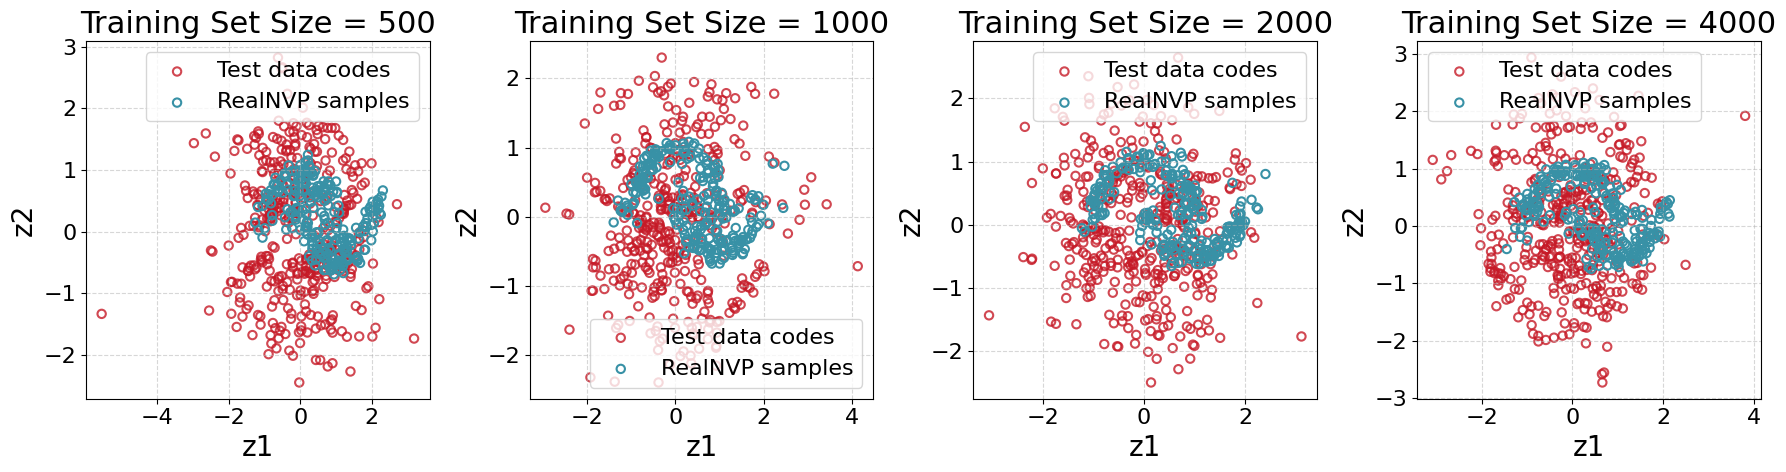

In [49]:
# Plot function
def plot_results(results_size, x_train, x_test, model, parameter_name, parameter_values, num_models = 4):
    fig, axes = plt.subplots(1, num_models, figsize=(18,5))
#    for params, losses in results_size:
 #       train_size = params[0]
  #      axes[0].plot(losses, label=f"Train size: {train_size}")

    #axes[0].set_xlabel("Epoch")
    #axes[0].set_ylabel("Negative Log-Likelihood")
    #axes[0].set_title("Effect of Training Set Size on RealNVP Training")
    #axes[0].legend()
    for i in range(num_models):
        params, losses, model = results_size[i]
        train_size = params[0]

        # Check codes for each model
        z_test, _ = model.forward(x_test)
        z_test = z_test.detach().numpy()
        axes[i].scatter(z_test[:,0], z_test[:,1], alpha = 0.8, label="Test data codes")
        axes[i].set_title(f"Code Distribution of Test Data (Size: {train_size})")
        axes[i].set_xlabel("z1")
        axes[i].set_ylabel("z2")

        # Generate samples for each model
        x_gen = model.sample(250)
        axes[i].scatter(x_gen[:,0], x_gen[:,1], label="RealNVP samples")
        axes[i].set_title(f"{parameter_name} = {train_size}")
        axes[i].legend()

    fig.tight_layout()
    plt.show()

plot_results(results_size, X_train, X_test, model, "Training Set Size", [size[0] for size in results_size])

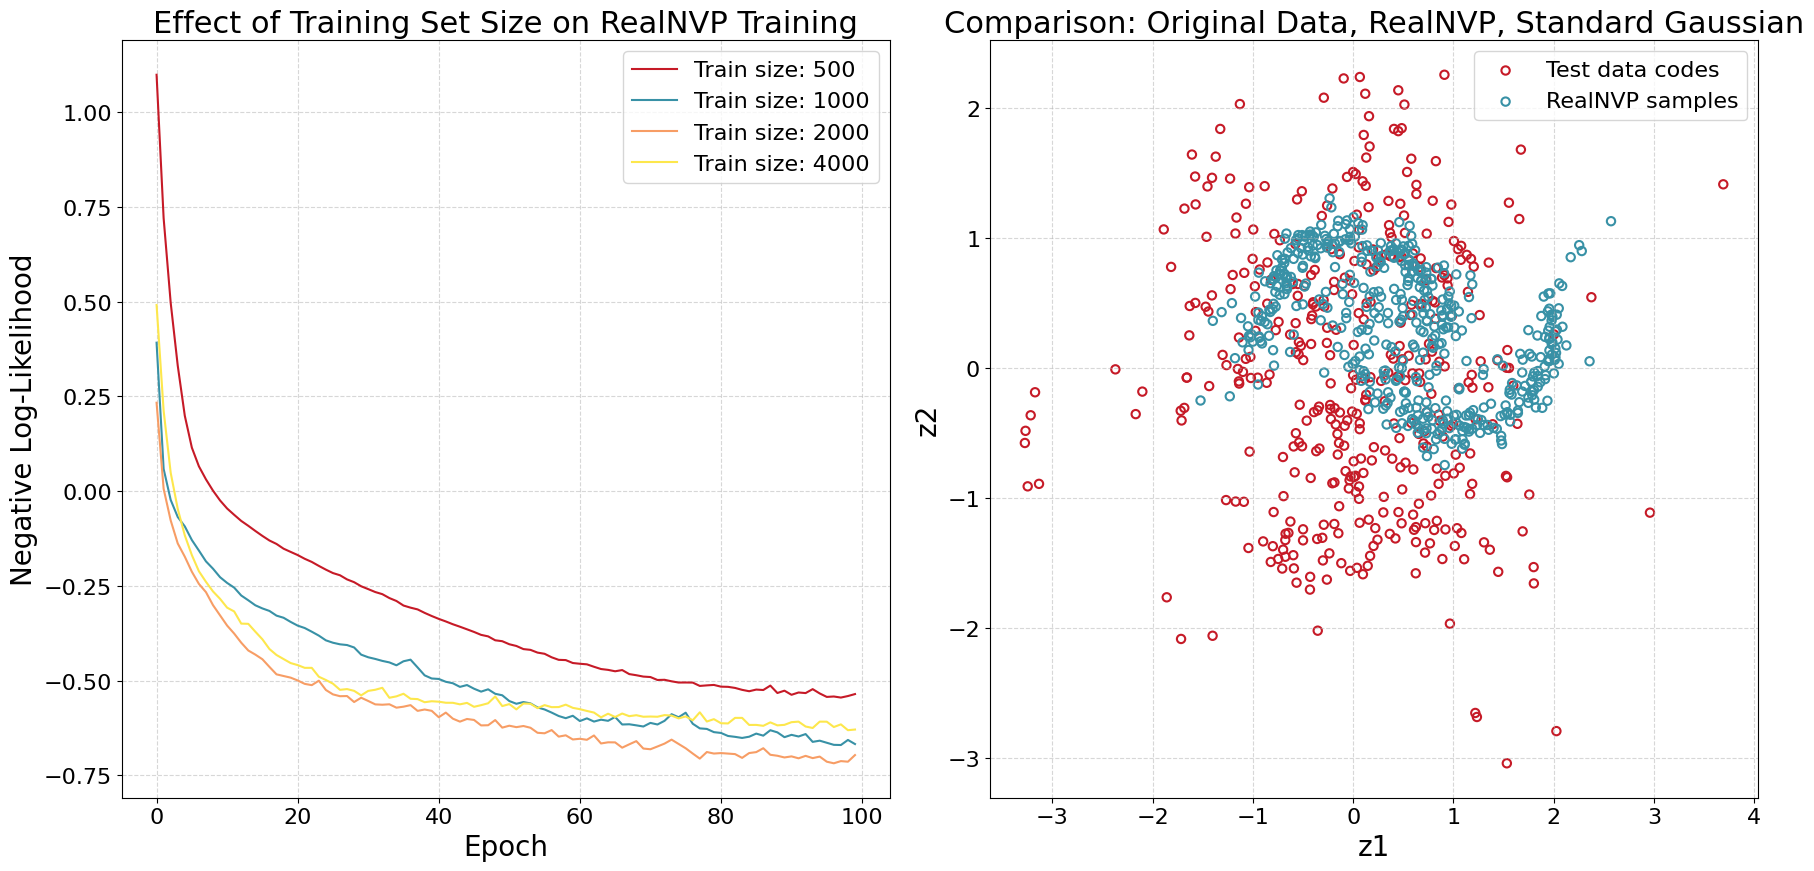

<Figure size 600x600 with 0 Axes>

In [34]:
# Plot 
fig, axes = plt.subplots(1, 2, figsize=(18,9))
for params, losses in results_size:
    train_size = params[0]
    axes[0].plot(losses, label=f"Train size: {train_size}")

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Negative Log-Likelihood")
axes[0].set_title("Effect of Training Set Size on RealNVP Training")
axes[0].legend()
#plt.show()

# Generate samples from trained model 
x_gen = model.sample(500)

# Check if code distribution is Gaussian
z_test, _ = model.forward(X_test)
z_test = z_test.detach().numpy()
    
plt.figure(figsize=(6,6))
axes[1].scatter(z_test[:,0], z_test[:,1], label="Test data codes")
axes[1].set_title("Code Distribution of Test Data")
axes[1].set_xlabel("z1")
axes[1].set_ylabel("z2")
axes[1].scatter(x_gen[:,0], x_gen[:,1], label="RealNVP samples")
axes[1].set_title("Comparison: Original Data, RealNVP, Standard Gaussian")
axes[1].legend()
fig.tight_layout()
plt.show()  

For the number of epochs in the end, the differences between training set size 1600,1000 and 500 are small, with 1600 only neing slightly better


Training with mini-batch size = 16
Epoch 1/200 | Loss: 0.3444 | Max Recon Err: 5.96e-07
Epoch 2/200 | Loss: 0.0042 | Max Recon Err: 7.15e-07
Epoch 3/200 | Loss: -0.0908 | Max Recon Err: 5.96e-07
Epoch 4/200 | Loss: -0.1512 | Max Recon Err: 7.15e-07
Epoch 5/200 | Loss: -0.2163 | Max Recon Err: 7.15e-07
Epoch 6/200 | Loss: -0.2820 | Max Recon Err: 5.96e-07
Epoch 7/200 | Loss: -0.3429 | Max Recon Err: 4.77e-07
Epoch 8/200 | Loss: -0.3789 | Max Recon Err: 5.96e-07
Epoch 9/200 | Loss: -0.4166 | Max Recon Err: 7.15e-07
Epoch 10/200 | Loss: -0.4168 | Max Recon Err: 7.15e-07
Epoch 11/200 | Loss: -0.4638 | Max Recon Err: 9.54e-07
Epoch 12/200 | Loss: -0.5106 | Max Recon Err: 8.34e-07
Epoch 13/200 | Loss: -0.4643 | Max Recon Err: 8.64e-07
Epoch 14/200 | Loss: -0.4950 | Max Recon Err: 1.01e-06
Epoch 15/200 | Loss: -0.5449 | Max Recon Err: 8.94e-07
Epoch 16/200 | Loss: -0.5627 | Max Recon Err: 8.34e-07
Epoch 17/200 | Loss: -0.5453 | Max Recon Err: 7.15e-07
Epoch 18/200 | Loss: -0.5753 | Max Recon

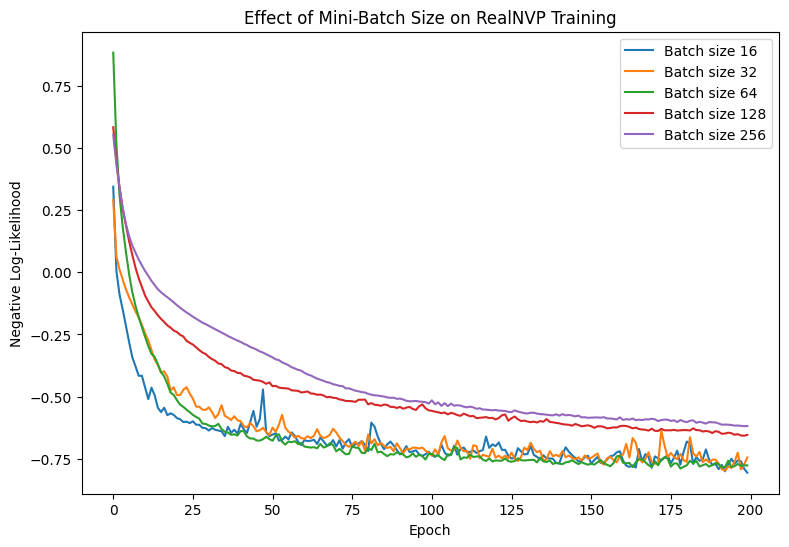

In [6]:
#Training for different mini-batch sizes
hyperparams_batch = [
    (500, 16,  200, 0.001, 32, 4),   
    (500, 32,  200, 0.001, 32, 4),   
    (500, 64,  200, 0.001, 32, 4),   
    (500, 128, 200, 0.001, 32, 4),   
    (500, 256, 200, 0.001, 32, 4)    
]

results_batch = []

for params in hyperparams_batch:
    train_size, batch, epochs, lr, hidden, blocks = params

    print(f"\nTraining with mini-batch size = {batch}")

    model = RealNVP(input_size=2, hidden_size=hidden, blocks=blocks)

    losses = train_realnvp(model,
                           X_train,
                           training_set_size=train_size,
                           mini_batch_size=batch,
                           n_epochs=epochs,
                           learning_rate=lr)

    results_batch.append((params, losses))

# Plot 
plt.figure(figsize=(9,6))
for params, losses in results_batch:
    batch_size = params[1]
    plt.plot(losses, label=f"Batch size {batch_size}")

plt.xlabel("Epoch")
plt.ylabel("Negative Log-Likelihood")
plt.title("Effect of Mini-Batch Size on RealNVP Training")
plt.legend()
plt.show()



The mini batch size f 32 provides the best results.


Training with 2 RealNVP blocks
Epoch 1/200 | Loss: 0.4373 | Max Recon Err: 2.38e-07
Epoch 2/200 | Loss: 0.2583 | Max Recon Err: 2.38e-07
Epoch 3/200 | Loss: 0.1829 | Max Recon Err: 2.38e-07
Epoch 4/200 | Loss: 0.1348 | Max Recon Err: 2.38e-07
Epoch 5/200 | Loss: 0.0912 | Max Recon Err: 2.38e-07
Epoch 6/200 | Loss: 0.0577 | Max Recon Err: 2.38e-07
Epoch 7/200 | Loss: 0.0327 | Max Recon Err: 2.38e-07
Epoch 8/200 | Loss: 0.0048 | Max Recon Err: 2.98e-07
Epoch 9/200 | Loss: -0.0117 | Max Recon Err: 2.38e-07
Epoch 10/200 | Loss: -0.0329 | Max Recon Err: 2.38e-07
Epoch 11/200 | Loss: -0.0545 | Max Recon Err: 2.38e-07
Epoch 12/200 | Loss: -0.0621 | Max Recon Err: 2.38e-07
Epoch 13/200 | Loss: -0.0752 | Max Recon Err: 2.38e-07
Epoch 14/200 | Loss: -0.0892 | Max Recon Err: 2.38e-07
Epoch 15/200 | Loss: -0.0932 | Max Recon Err: 2.98e-07
Epoch 16/200 | Loss: -0.1070 | Max Recon Err: 2.38e-07
Epoch 17/200 | Loss: -0.1207 | Max Recon Err: 2.38e-07
Epoch 18/200 | Loss: -0.1203 | Max Recon Err: 2.38

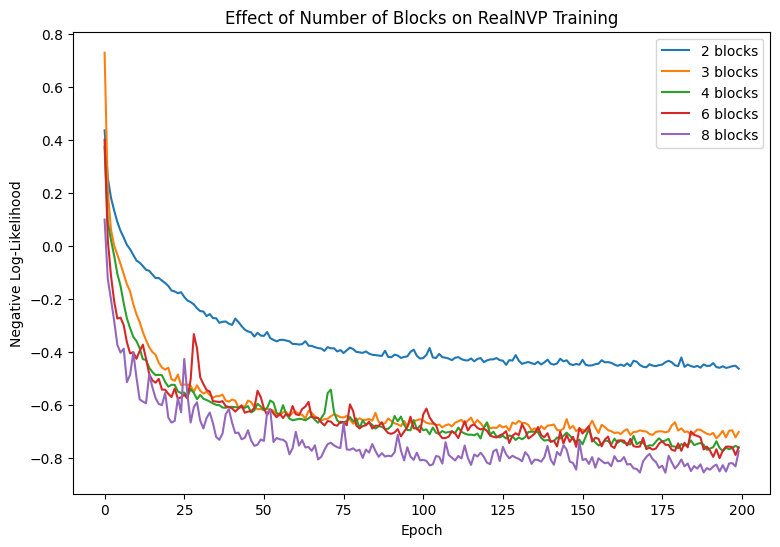

In [7]:
#training with different number of blocks
hyperparams_blocks = [
    (500, 32, 200, 0.001, 32, 2),   
    (500, 32, 200, 0.001, 32, 3),   
    (500, 32, 200, 0.001, 32, 4),   
    (500, 32, 200, 0.001, 32, 6),   
    (500, 32, 200, 0.001, 32, 8),   
]

results_blocks = []

for params in hyperparams_blocks:
    train_size, batch, epochs, lr, hidden, blocks = params

    print(f"\nTraining with {blocks} RealNVP blocks")

    model = RealNVP(input_size=2, hidden_size=hidden, blocks=blocks)

    losses = train_realnvp(model,
                           X_train,
                           training_set_size=train_size,
                           mini_batch_size=batch,
                           n_epochs=epochs,
                           learning_rate=lr)

    results_blocks.append((params, losses))


# ---- Plot curves ----
plt.figure(figsize=(9,6))
for params, losses in results_blocks:
    blocks = params[-1]
    plt.plot(losses, label=f"{blocks} blocks")

plt.xlabel("Epoch")
plt.ylabel("Negative Log-Likelihood")
plt.title("Effect of Number of Blocks on RealNVP Training")
plt.legend()
plt.show()

8 blocks and 6 blocks only slightly differ. Rest has higher loss.

### Now training with 2 Moons at noise level 0.1 

Epoch 1/200 | Loss: 0.8411 | Max Recon Err: 1.07e-06
Epoch 2/200 | Loss: 0.6070 | Max Recon Err: 1.07e-06
Epoch 3/200 | Loss: 0.4220 | Max Recon Err: 1.19e-06
Epoch 4/200 | Loss: 0.2857 | Max Recon Err: 1.07e-06
Epoch 5/200 | Loss: 0.1798 | Max Recon Err: 9.54e-07
Epoch 6/200 | Loss: 0.1183 | Max Recon Err: 1.19e-06
Epoch 7/200 | Loss: 0.0893 | Max Recon Err: 9.54e-07
Epoch 8/200 | Loss: 0.0658 | Max Recon Err: 1.07e-06
Epoch 9/200 | Loss: 0.0479 | Max Recon Err: 1.07e-06
Epoch 10/200 | Loss: 0.0234 | Max Recon Err: 9.54e-07
Epoch 11/200 | Loss: 0.0026 | Max Recon Err: 1.19e-06
Epoch 12/200 | Loss: -0.0202 | Max Recon Err: 1.19e-06
Epoch 13/200 | Loss: -0.0384 | Max Recon Err: 9.54e-07
Epoch 14/200 | Loss: -0.0553 | Max Recon Err: 1.19e-06
Epoch 15/200 | Loss: -0.0696 | Max Recon Err: 1.19e-06
Epoch 16/200 | Loss: -0.0813 | Max Recon Err: 9.54e-07
Epoch 17/200 | Loss: -0.0901 | Max Recon Err: 1.19e-06
Epoch 18/200 | Loss: -0.0987 | Max Recon Err: 1.19e-06
Epoch 19/200 | Loss: -0.1054 |

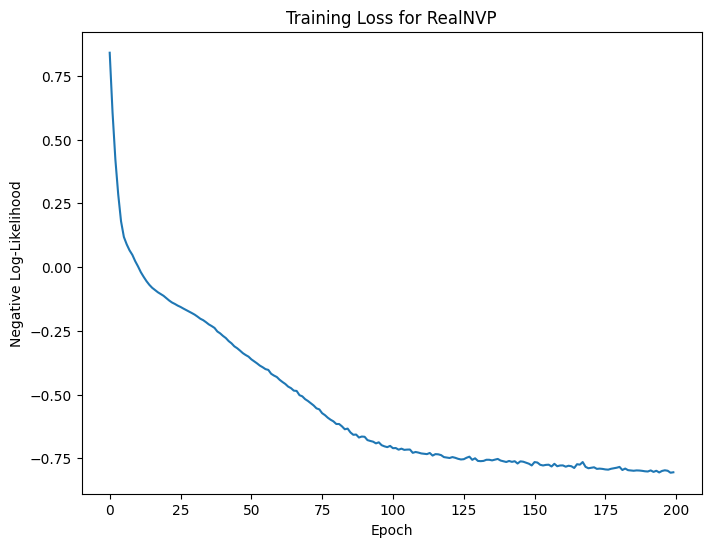

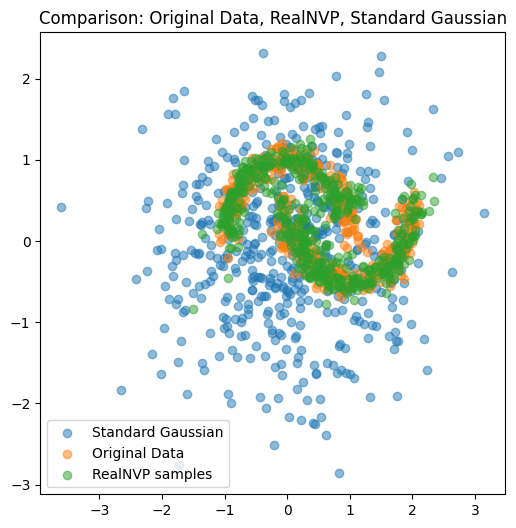

In [8]:
X, _ = make_moons(n_samples=2000, noise=0.1)
X = torch.tensor(X, dtype=torch.float32)
X_train, X_test = train_test_split(X, test_size=0.2, shuffle=True)
model = RealNVP(input_size=2, hidden_size=32, blocks=6)


losses = train_realnvp(model,
                       X_train,
                       training_set_size=train_size,
                       mini_batch_size=batch_size,
                       n_epochs=200,
                       learning_rate=0.001)

#Plot training loss 
plt.figure(figsize=(8,6))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Negative Log-Likelihood")
plt.title("Training Loss for RealNVP")
plt.show()

# Generate samples from trained model 
x_gen = model.sample(500)

# Compare to standard Gaussian 
z_gauss = np.random.randn(500, 2)

plt.figure(figsize=(6,6))
plt.scatter(z_gauss[:,0], z_gauss[:,1], alpha=0.5, label="Standard Gaussian")
plt.scatter(X_test[:,0], X_test[:,1], alpha=0.5, label="Original Data")
plt.scatter(x_gen[:,0], x_gen[:,1], alpha=0.5, label="RealNVP samples")
plt.title("Comparison: Original Data, RealNVP, Standard Gaussian")
plt.legend()
plt.show()  

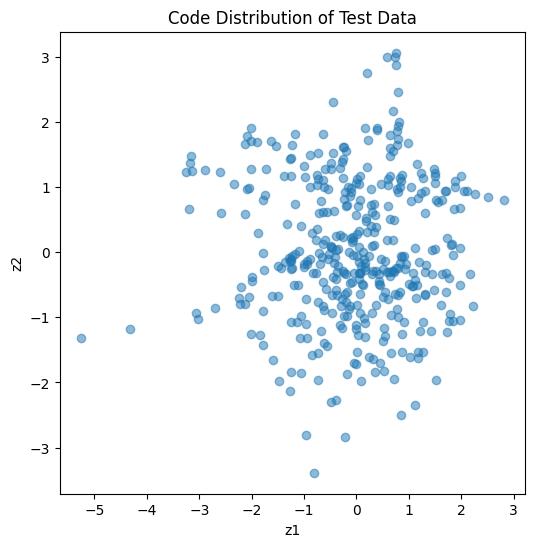

As we can see, the sampled data matches the two moons dataset much better than a randon gaussian distribution.

#### Hexagon task

In [9]:
def generate_hexagon_gmm(radius=1.0, points_per_cluster=300):
    angles = np.linspace(0, 2*np.pi, 6, endpoint=False)  # 6 corners
    centers = np.stack([radius*np.cos(angles), radius*np.sin(angles)], axis=1)
    
    X_list = []
    for c in centers:
        cluster = np.random.randn(points_per_cluster, 2) * (radius/10) + c
        X_list.append(cluster)
    X = np.vstack(X_list)
    return torch.tensor(X, dtype=torch.float32)

# Example
X_gmm = generate_hexagon_gmm(radius=1.0, points_per_cluster=300)

# Train-test split
X_train_gmm, X_test_gmm = train_test_split(X_gmm, test_size=0.2, shuffle=True)


In [10]:
model_gmm = RealNVP(input_size=2, hidden_size=32, blocks=6)

losses_gmm = train_realnvp(model_gmm,
                           X_train_gmm,
                           training_set_size=500,
                           mini_batch_size=31,
                           n_epochs=200,
                           learning_rate=0.001)


Epoch 1/200 | Loss: 0.3613 | Max Recon Err: 4.77e-07
Epoch 2/200 | Loss: 0.1505 | Max Recon Err: 4.77e-07
Epoch 3/200 | Loss: 0.0079 | Max Recon Err: 4.17e-07
Epoch 4/200 | Loss: -0.1244 | Max Recon Err: 4.17e-07
Epoch 5/200 | Loss: -0.2753 | Max Recon Err: 4.77e-07
Epoch 6/200 | Loss: -0.4092 | Max Recon Err: 5.96e-07
Epoch 7/200 | Loss: -0.4532 | Max Recon Err: 6.56e-07
Epoch 8/200 | Loss: -0.5631 | Max Recon Err: 5.36e-07
Epoch 9/200 | Loss: -0.6324 | Max Recon Err: 6.56e-07
Epoch 10/200 | Loss: -0.7328 | Max Recon Err: 1.07e-06
Epoch 11/200 | Loss: -0.7766 | Max Recon Err: 4.77e-07
Epoch 12/200 | Loss: -0.8267 | Max Recon Err: 8.34e-07
Epoch 13/200 | Loss: -0.8083 | Max Recon Err: 8.34e-07
Epoch 14/200 | Loss: -0.7888 | Max Recon Err: 5.96e-07
Epoch 15/200 | Loss: -0.8566 | Max Recon Err: 5.96e-07
Epoch 16/200 | Loss: -0.9611 | Max Recon Err: 5.96e-07
Epoch 17/200 | Loss: -0.9833 | Max Recon Err: 5.96e-07
Epoch 18/200 | Loss: -1.0132 | Max Recon Err: 5.96e-07
Epoch 19/200 | Loss: -

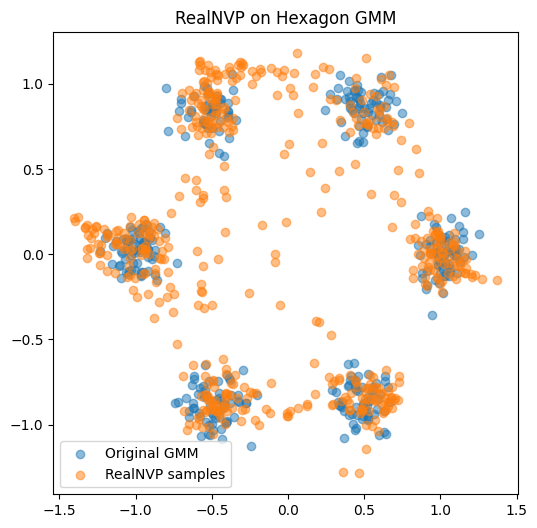

In [11]:
x_gen_gmm = model_gmm.sample(500)

plt.figure(figsize=(6,6))
plt.scatter(X_test_gmm[:,0], X_test_gmm[:,1], alpha=0.5, label="Original GMM")
plt.scatter(x_gen_gmm[:,0], x_gen_gmm[:,1], alpha=0.5, label="RealNVP samples")
plt.title("RealNVP on Hexagon GMM")
plt.legend()
plt.show()


We can definitely see the hexagonal distribution of the data points, our learned samples differ a bit, mostly around the outer conections of the hexagon.